In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.optimize import root
from scipy.special import kv

file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"

# ==========================================================
# SCENARI ADAF
# ==========================================================
SCENARI_ADAF = [
    {
        "scenario": r"LBL: $\dot m$ =5.7e-3",
        "m": 1e9,
        "mdot": 5.7e-3,
        "beta": 0.5
    },
    {
        "scenario": r"IBL: $\dot m$ =5e-4",
        "m": 1e9,
        "mdot": 5.0e-4,
        "beta": 0.5
    },
    {
        "scenario": r"HBL: $\dot m$ =3e-4",
        "m": 1e9,
        "mdot": 3.0e-4,
        "beta": 0.5
    }
]

# ==========================================================
# COSTANTI
# ==========================================================
ALFA = 0.3
RMIN = 3.0
RMAX = 1000.0
DELTA = 0.0
C1 = 0.5
C3 = 0.3
TNORM = 1.68e-10

# ==========================================================
# FUNZIONI MATEMATICHE
# ==========================================================
def bessk(n, x):
    return kv(n, x)

def g(teta):
    return (1.0 / bessk(2, 1.0 / teta)) * (2.0 + 2.0 * teta + 1.0 / teta) * np.exp(-1.0 / teta)

# ==========================================================
# SISTEMA NON LINEARE
# ==========================================================
def temperat(y, mdot, m, beta):

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    teta = y[0]**2

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm

    # Heating
    q1 = 1.2e4 * g(teta) * ALFA**(-2) * C1**(-2) * C3 * beta * m * mdot**2 / RMIN
    q2 = DELTA * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN
    q = q1 + q2

    # Synchrotron
    nup = s1 * s2 * m**(-0.5) * mdot**0.5 * (teta / TNORM)**2 * RMIN**(-5/4)
    psinc = (
        53.0 * (xm / 1000.0)**3 *
        (teta / (1e9 * TNORM))**7 *
        m**0.5 * mdot**1.5
    )

    # Compton inverso
    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)
    graffa = ((6.2e7 * (teta / (1e9 * TNORM))) / (nup * 1e-12))**(1 - alfac) - 1
    pcomp = (psinc / 0.71) / (1 - alfac) * graffa

    # Bremsstrahlung
    if teta < 1:
        f = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
    else:
        f = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

    pbrems = 4.78 * ALFA**(-2) * C1**(-2) * np.log(RMAX/RMIN) * f * m * mdot**2

    # Equazioni
    f1 = q - psinc - pcomp - pbrems
    f2 = (1 - ff) * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN - q

    vv = xm**(1/3)
    f3 = (
        vv + 1.852*np.log(vv)
        - 10.36
        - 0.26*np.log(m*mdot)
        + 0.26*np.log(teta**3 * bessk(2, 1/teta))
    )

    return [f1, f3, f2]

# ==========================================================
# SPETTRO
# ==========================================================
def spectrum(te, f, xm, m, mdot, beta, savefile=None):

    numin = 1e10
    numax = 1e21
    num = 100

    lnu = np.linspace(np.log10(numin), np.log10(numax), num)
    nu = 10**lnu

    teta = 1.68e-10 * te

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm
    s3 = 1.05e-24
    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    lnup = np.log10(s1 * s2 * m**(-0.5) * mdot**0.5 * te**2 * RMIN**(-5/4))
    lnucmax = np.log10(te) + 10.796

    llsinc = (
        3*np.log10(s1*s2)
        + np.log10(s3)
        - (7/4)*np.log10(RMIN)
        + np.log10(m**0.5 * mdot**1.5)
        + 7*np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    for i in range(num):
        # SYNCHROTRON
        if lnu[i] < lnup:
            lls[i] = (
                np.log10(s3)
                + (8/5)*np.log10(s1*s2)
                + np.log10(m**(6/5) * mdot**(4/5))
                + (21/5)*np.log10(te)
                + (2/5)*lnu[i]
            )
        else:
            lls[i] = -np.inf

        # COMPTON
        if lnu[i] > lnup:
            base = llsinc + (alfac - 1)*lnup - alfac*lnu[i]
            cutoff = -(10**(lnu[i] - lnucmax)) / np.log(10)
            llc[i] = base + cutoff
        else:
            llc[i] = -np.inf

        # BREMS
        if teta < 1:
            fb = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
        else:
            fb = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

        base_b = (
            24.36
            - 2*np.log10(ALFA*C1)
            + np.log10(np.log(RMAX/RMIN) * fb)
            - np.log10(te)
            + np.log10(m * mdot**2)
        )
        cutoff_b = -(4.8e-11 * nu[i] / te) / np.log(10)
        llb[i] = base_b + cutoff_b

    comp_sync = np.where(np.isfinite(lls), 10**lls, 0.0)
    comp_comp = np.where(np.isfinite(llc), 10**llc, 0.0)
    comp_brems = np.where(np.isfinite(llb), 10**llb, 0.0)

    flux = comp_sync + comp_comp + comp_brems
    y = lnu + np.log10(flux)

    if savefile is not None:
        np.savetxt(savefile, np.column_stack([lnu, y]))
        print(f"File salvato: {savefile}")

    return lnu, y, lls, llc, llb


# ==========================================================
# SPECDATA
# ==========================================================
def specdata(m, mdot, beta, savefile=None, verbose=True):

    if verbose:
        print(f"m = {m}")
        print(f"mdot = {mdot}")
        print(f"beta = {beta}")

    y0 = [0.5, 1.0, 0.99]
    sol = root(temperat, y0, args=(mdot, m, beta), tol=1e-10)

    if not sol.success:
        raise RuntimeError(f"La soluzione non converge per m={m}, mdot={mdot}, beta={beta}")

    y = sol.x
    teta = y[0]**2
    te = teta / 1.68e-10
    xm = 1e3 * y[1]**2
    f = y[2]**2

    if verbose:
        print("\n=== OUTPUT ===")
        print("te   =", te)
        print("xm   =", xm)
        print("f    =", f)

    lnu, spettro_tot, lls, llc, llb = spectrum(
        te, f, xm, m, mdot, beta, savefile=savefile
    )

    return {
        "lnu": lnu,
        "log_nuFnu": spettro_tot,
        "log_sync": lls,
        "log_compton": llc,
        "log_brems": llb,
        "te": te,
        "xm": xm,
        "f": f,
        "m": m,
        "mdot": mdot,
        "beta": beta
    }

# ==========================================================
# COSTANTI PER IL CALCOLO DELLE RIGHE
# stessa prescrizione usata nel programma SS
# ==========================================================

# Costanti fisiche CGS necessarie per Q(H) e Case B
c = 2.99792458e10          # cm/s
h = 6.62607015e-27         # erg s
eV_to_erg = 1.602176634e-12

# Estremo superiore degli integrali ionizzanti.
# Scelto uguale al programma SS per rendere il confronto omogeneo.
NU_ION_MAX = 1e17

# Case B / Osterbrock, T = 10^4 K
alpha_B = 2.59e-13         # cm^3 s^-1
alpha_eff = {
    "Ha": 1.16e-13,
    "Hb": 3.07e-14,
    "Hg": 1.29e-14,
    "Hd": 6.79e-15,
}

lambda_balmer_A = {
    "Ha": 6563.0,
    "Hb": 4861.0,
    "Hg": 4340.0,
    "Hd": 4102.0,
}

lambda_balmer_cm = {
    line_name: wavelength_A * 1e-8
    for line_name, wavelength_A in lambda_balmer_A.items()
}

nu_balmer_line = {
    line_name: c / wavelength_cm
    for line_name, wavelength_cm in lambda_balmer_cm.items()
}

# Soglia comune di ionizzazione dell'idrogeno
E_H_ion_eV = 13.6
E_H_ion_erg = E_H_ion_eV * eV_to_erg
nu_H_ion = E_H_ion_erg / h

BALMER_LINES = ["Ha", "Hb", "Hg", "Hd"]
METAL_LINES = ["MgII", "CIII", "CIV"]
MODEL_LINES = BALMER_LINES + METAL_LINES


# ==========================================================
# FUNZIONI DI SUPPORTO
# ==========================================================

def trova_colonna(df, possibili_nomi, obbligatoria=True):
    for nome in possibili_nomi:
        if nome in df.columns:
            return nome
    if obbligatoria:
        raise ValueError(f"Non trovo nessuna di queste colonne: {possibili_nomi}")
    return None


def leggi_transizioni(file_transizioni):
    """
    Legge dati.asc con 3 colonne:
        nome_transizione   E_ion   nu_ion

    Le nu_ion del file sono usate soltanto per MgII, CIII e CIV.
    Per le Balmer la soglia ionizzante è sempre quella dell'idrogeno,
    13.6 eV, come nel programma SS.
    """
    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=("U50", float, float),
        unpack=True,
    )

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list,
    })


def estrai_linee_osservate(row, norm_columns):
    """Estrae soltanto le linee usate dal modello, se positive."""
    risultati = []

    for col in norm_columns:
        valore = row[col]

        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace("_norm", "")
        if line_name not in MODEL_LINES:
            continue

        L_line_obs = valore * 1e42

        risultati.append({
            "line_name": line_name,
            "norm_value": valore,
            "L_line_obs": L_line_obs,
        })

    return pd.DataFrame(risultati)


# ==========================================================
# COSTRUZIONE SPETTRO ADAF
# ==========================================================

def costruisci_spettro_adaf(m, mdot, beta, verbose=False):
    """
    Usa specdata() e restituisce:
        nu      [Hz]
        Lnu     [erg s^-1 Hz^-1]
        nuLnu   [erg s^-1]
        info    dict con parametri fisici ADAF
    """
    risultato = specdata(
        m=m,
        mdot=mdot,
        beta=beta,
        verbose=verbose,
    )

    lnu = risultato["lnu"]
    log_nuLnu = risultato["log_nuFnu"]

    nu = 10**lnu
    nuLnu = 10**log_nuLnu
    Lnu = nuLnu / nu

    info = {
        "m": m,
        "mdot": mdot,
        "beta": beta,
        "te": risultato["te"],
        "xm": risultato["xm"],
        "f": risultato["f"],
    }

    return nu, Lnu, nuLnu, info


# ==========================================================
# BALMER: Q(H) + CASE B / OSTERBROCK
# ==========================================================

def calcola_Q_H(nu, Lnu, nu_H_ion=nu_H_ion, nu_max=NU_ION_MAX):
    """
    Numero di fotoni ionizzanti dell'idrogeno:

        Q(H) = integral [Lnu / (h nu)] dnu

    da 13.6 eV fino a nu_max.
    """
    nu_max_eff = min(nu_max, np.max(nu))
    mask = (nu >= nu_H_ion) & (nu <= nu_max_eff)

    if np.sum(mask) < 2:
        return 0.0

    integrand = Lnu[mask] / (h * nu[mask])
    return np.trapezoid(integrand, nu[mask])


def calcola_luminosita_balmer_cf1(Q_H):
    """
    Luminosità teorica delle Balmer per Cf = 1:

        L_line(Cf=1) = h nu_line (alpha_eff / alpha_B) Q(H)
    """
    risultati = []

    for line_name in BALMER_LINES:
        nu_line = nu_balmer_line[line_name]
        alpha_line = alpha_eff[line_name]

        L_line_cf1 = (
            h
            * nu_line
            * (alpha_line / alpha_B)
            * Q_H
        )

        risultati.append({
            "line_name": line_name,
            "line_model": "Balmer_CaseB",
            "E_ion": E_H_ion_eV,
            "nu_line": nu_line,
            "nu_ion": nu_H_ion,
            "Q_H": Q_H,
            "L_ion": np.nan,
            "L_line_cf1": L_line_cf1,
        })

    return pd.DataFrame(risultati)


# ==========================================================
# MgII, CIII, CIV: INTEGRALE DELLA LUMINOSITA' IONIZZANTE
# ==========================================================

def calcola_lion_metalli(nu, Lnu, df_trans, nu_max=NU_ION_MAX):
    """
    Per MgII, CIII e CIV:

        L_ion = integral Lnu dnu

    dalla nu_ion di dati.asc fino a nu_max.

    Con la prescrizione adottata:
        L_line = Cf * L_ion
    quindi per Cf=1:
        L_line_cf1 = L_ion
    """
    risultati = []
    nu_max_eff = min(nu_max, np.max(nu))

    df_metalli = df_trans[
        df_trans["line_name"].isin(METAL_LINES)
    ].copy()

    for _, row in df_metalli.iterrows():
        line_name = row["line_name"]
        E_ion = row["E_ion"]
        nu_ion = row["nu_ion"]

        if nu_ion >= nu_max_eff:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max_eff)

            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        risultati.append({
            "line_name": line_name,
            "line_model": "Cf_times_Lion",
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "nu_line": np.nan,
            "Q_H": np.nan,
            "L_ion": L_ion,
            "L_line_cf1": L_ion,
        })

    return pd.DataFrame(risultati)


def calcola_luminosita_teoriche(nu, Lnu, df_trans, nu_max=NU_ION_MAX):
    """
    Costruisce in un unico DataFrame le luminosità teoriche per Cf=1:
      - Balmer: Q(H) + Case B/Osterbrock
      - MgII/CIII/CIV: integrale di Lnu sopra la rispettiva nu_ion
    """
    Q_H = calcola_Q_H(
        nu,
        Lnu,
        nu_H_ion=nu_H_ion,
        nu_max=nu_max,
    )

    df_balmer = calcola_luminosita_balmer_cf1(Q_H)
    df_metalli = calcola_lion_metalli(
        nu,
        Lnu,
        df_trans,
        nu_max=nu_max,
    )

    df_teorico = pd.concat(
        [df_balmer, df_metalli],
        ignore_index=True,
        sort=False,
    )

    return df_teorico, Q_H


# ==========================================================
# GRAFICO DELLO SPETTRO ADAF E SOGLIE USATE
# ==========================================================

def fai_grafico_spettro_adaf(nu, Lnu, df_trans, nome_blazar, scenario_name):
    plt.figure(figsize=(9, 6))

    plt.loglog(
        nu,
        Lnu,
        color="black",
        lw=2,
        label=r"$L_\nu$ ADAF",
    )

    plt.axvline(
        nu_H_ion,
        color="red",
        lw=2,
        linestyle="--",
        alpha=0.8,
        label="H ionizzazione (13.6 eV)",
    )

    cmap = plt.get_cmap("tab10")
    df_metalli = df_trans[
        df_trans["line_name"].isin(METAL_LINES)
    ].copy()

    for i, (_, row) in enumerate(df_metalli.iterrows()):
        plt.axvline(
            row["nu_ion"],
            color=cmap(i),
            lw=1.5,
            alpha=0.8,
            label=row["line_name"],
        )

    plt.xlabel(r"$\nu$ [Hz]")
    plt.ylabel(r"$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]")
    plt.title(f"Spettro ADAF - {nome_blazar} - {scenario_name}")
    plt.xlim(nu.min(), nu.max())
    plt.legend(fontsize=8, bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout()
    plt.show()


# ==========================================================
# LETTURA DATI OSSERVATIVI
# ==========================================================

df_tab = pd.read_csv(file_linee)
df_trans = leggi_transizioni(file_transizioni)

col_name_tab = trova_colonna(
    df_tab,
    ["label", "file_name", "name", "nome", "blazar"],
)

norm_columns = [
    col for col in df_tab.columns
    if col.endswith("_norm")
]

df_all = df_tab.rename(
    columns={col_name_tab: "label"}
).copy()

print("=" * 80)
print("FREQUENZE UTILIZZATE NEL MODELLO ADAF")
print("=" * 80)
print(f"Soglia H 13.6 eV = {nu_H_ion:.4e} Hz")
print(f"Estremo superiore integrali = {NU_ION_MAX:.4e} Hz")
print()
print("Frequenze delle righe Balmer emesse:")
for line_name in BALMER_LINES:
    print(
        f"{line_name:4s} | "
        f"lambda = {lambda_balmer_A[line_name]:.1f} A | "
        f"nu_line = {nu_balmer_line[line_name]:.4e} Hz"
    )

print()
print("Frequenze nu_ion dei metalli da dati.asc:")
for _, row in df_trans[
    df_trans["line_name"].isin(METAL_LINES)
].iterrows():
    print(
        f"{row['line_name']:4s} | "
        f"E = {row['E_ion']:.3f} eV | "
        f"nu_ion = {row['nu_ion']:.4e} Hz"
    )
print("=" * 80)


# ==========================================================
# ANALISI DI UN SINGOLO BLAZAR
# ==========================================================

def analizza_blazar_adaf(
    row,
    df_trans,
    norm_columns,
    mostra_grafico=True,
    verbose=True,
):
    nome_blazar = row["label"]
    m = row["m"]
    mdot = row["mdot"]
    beta = row["beta"]
    scenario_name = row["scenario"]
    redshift = row["redshift"] if "redshift" in row.index else np.nan

    if verbose:
        print("=" * 80)
        print(f"Scenario = {scenario_name}")
        print(f"Blazar = {nome_blazar}")
        print(f"redshift = {redshift}")
        print(f"m = {m:.3e} Msun")
        print(f"mdot = {mdot:.3e}")
        print(f"beta = {beta:.3f}")

    # Spettro ADAF
    nu, Lnu, nuLnu, info = costruisci_spettro_adaf(
        m=m,
        mdot=mdot,
        beta=beta,
        verbose=False,
    )

    if verbose:
        print()
        print("Parametri fisici ADAF:")
        print(f"te = {info['te']:.3e}")
        print(f"xm = {info['xm']:.3e}")
        print(f"f  = {info['f']:.3e}")

    # Luminosità teoriche per Cf=1 con due prescrizioni diverse
    df_teorico, Q_H = calcola_luminosita_teoriche(
        nu,
        Lnu,
        df_trans,
        nu_max=NU_ION_MAX,
    )

    if verbose:
        print()
        print(f"Q(H) = {Q_H:.6e} photons/s")

    # Linee osservate
    df_linee = estrai_linee_osservate(row, norm_columns)

    if verbose:
        print()
        print("Linee osservate del blazar:")
        display(df_linee)

    # Confronto osservato - teorico
    df_conf = df_linee.merge(
        df_teorico,
        on="line_name",
        how="left",
    )

    # Cf = L_obs / L_theory(Cf=1)
    df_conf["covering_factor"] = (
        df_conf["L_line_obs"]
        / df_conf["L_line_cf1"]
    )

    df_conf.loc[
        df_conf["L_line_cf1"].isna()
        | (df_conf["L_line_cf1"] <= 0),
        "covering_factor",
    ] = np.nan

    # Stessi diagnostici del programma SS
    df_conf["L_line_Cf_0p1"] = 0.1 * df_conf["L_line_cf1"]
    df_conf["model_over_obs_Cf_0p1"] = (
        df_conf["L_line_Cf_0p1"]
        / df_conf["L_line_obs"]
    )

    if verbose:
        print()
        print("Confronto finale per ogni linea:")
        colonne_output = [
            "line_name",
            "line_model",
            "L_line_obs",
            "L_line_cf1",
            "L_line_Cf_0p1",
            "model_over_obs_Cf_0p1",
            "covering_factor",
            "Q_H",
            "L_ion",
        ]
        display(df_conf[colonne_output])

    if mostra_grafico:
        fai_grafico_spettro_adaf(
            nu,
            Lnu,
            df_trans,
            nome_blazar,
            scenario_name,
        )

    return df_conf


# ==========================================================
# ANALISI DI TUTTI I BLAZAR IN TUTTI GLI SCENARI ADAF
# ==========================================================

tutti_risultati_scenari_adaf = []

for scenario in SCENARI_ADAF:
    df_all_scenario = df_all.copy()
    df_all_scenario["m"] = scenario["m"]
    df_all_scenario["mdot"] = scenario["mdot"]
    df_all_scenario["beta"] = scenario["beta"]
    df_all_scenario["scenario"] = scenario["scenario"]

    risultati_scenario = []

    for i in range(len(df_all_scenario)):
        row = df_all_scenario.iloc[i]

        df_conf = analizza_blazar_adaf(
            row,
            df_trans,
            norm_columns,
            mostra_grafico=False,
            verbose=False,
        )

        df_conf["label"] = row["label"]
        df_conf["scenario"] = scenario["scenario"]
        df_conf["m"] = scenario["m"]
        df_conf["mdot"] = scenario["mdot"]
        df_conf["beta"] = scenario["beta"]

        risultati_scenario.append(df_conf)

    if risultati_scenario:
        df_risultati_scenario = pd.concat(
            risultati_scenario,
            ignore_index=True,
        )
        tutti_risultati_scenari_adaf.append(df_risultati_scenario)


df_risultati_finali_adaf = pd.concat(
    tutti_risultati_scenari_adaf,
    ignore_index=True,
)

print("=" * 100)
print("DataFrame finale ADAF creato")
print(f"Numero righe: {len(df_risultati_finali_adaf)}")
display(df_risultati_finali_adaf.head())


# ==========================================================
# TABELLE PER BLAZAR - STESSO FORMATO SS
# ==========================================================

tabelle_per_blazar_adaf = {}

blazar_unici = sorted(
    df_risultati_finali_adaf["label"].unique()
)

ordine_scenari_adaf = [
    s["scenario"] for s in SCENARI_ADAF
]

ordine_linee_tabella = [
    "Ha", "Hb", "Hg", "Hd", "MgII", "CIII", "CIV"
]

for blazar in blazar_unici:
    df_blazar = df_risultati_finali_adaf[
        df_risultati_finali_adaf["label"] == blazar
    ].copy()

    tabella_blazar = df_blazar.pivot(
        index="scenario",
        columns="line_name",
        values="covering_factor",
    )

    colonne_presenti = [
        linea
        for linea in ordine_linee_tabella
        if linea in tabella_blazar.columns
    ]

    tabella_blazar = tabella_blazar[colonne_presenti]
    tabella_blazar = (
        tabella_blazar
        .reindex(ordine_scenari_adaf)
        .reset_index()
        .fillna("-")
    )

    tabelle_per_blazar_adaf[blazar] = tabella_blazar

print(
    f"Tabelle create per blazar: "
    f"{len(tabelle_per_blazar_adaf)}"
)

for blazar, tabella in tabelle_per_blazar_adaf.items():
    print("\n" + "=" * 100)
    print(f"Blazar: {blazar}")
    display(tabella)


# ==========================================================
# TABELLE PER SCENARIO - STESSO FORMATO SS
# ==========================================================

tabelle_per_scenario_adaf = {}

for scenario in ordine_scenari_adaf:
    df_scenario = df_risultati_finali_adaf[
        df_risultati_finali_adaf["scenario"] == scenario
    ].copy()

    tabella_scenario = df_scenario.pivot(
        index="label",
        columns="line_name",
        values="covering_factor",
    )

    colonne_presenti = [
        linea
        for linea in ordine_linee_tabella
        if linea in tabella_scenario.columns
    ]

    tabella_scenario = (
        tabella_scenario[colonne_presenti]
        .reset_index()
        .fillna("-")
    )

    tabelle_per_scenario_adaf[scenario] = tabella_scenario

for scenario in ordine_scenari_adaf:
    print("\n" + "=" * 100)
    print(f"Scenario: {scenario}")
    display(tabelle_per_scenario_adaf[scenario])


FREQUENZE UTILIZZATE NEL MODELLO ADAF
Soglia H 13.6 eV = 3.2885e+15 Hz
Estremo superiore integrali = 1.0000e+17 Hz

Frequenze delle righe Balmer emesse:
Ha   | lambda = 6563.0 A | nu_line = 4.5679e+14 Hz
Hb   | lambda = 4861.0 A | nu_line = 6.1673e+14 Hz
Hg   | lambda = 4340.0 A | nu_line = 6.9077e+14 Hz
Hd   | lambda = 4102.0 A | nu_line = 7.3084e+14 Hz

Frequenze nu_ion dei metalli da dati.asc:
MgII | E = 7.600 eV | nu_ion = 1.8380e+15 Hz
CIII | E = 24.380 eV | nu_ion = 5.8900e+15 Hz
CIV  | E = 47.900 eV | nu_ion = 1.1580e+16 Hz
DataFrame finale ADAF creato
Numero righe: 117


,line_name,norm_value,L_line_obs,line_model,E_ion,nu_line,nu_ion,Q_H,L_ion,L_line_cf1,covering_factor,L_line_Cf_0p1,model_over_obs_Cf_0p1,label,scenario,m,mdot,beta
0,Ha,3.631777,3.631777e+42,Balmer_CaseB,13.6,4.567918e+14,3.288465e+15,2.477914e+52,NaN,3.359068e+40,108.118593,3.359068e+39,0.000925,J1745.6,LBL: $\dot m$ =5.7e-3,1.000000e+09,0.0057,0.5
1,Hb,1.103068,1.103068e+42,Balmer_CaseB,13.6,6.167300e+14,3.288465e+15,2.477914e+52,NaN,1.200262e+40,91.902264,1.200262e+39,0.001088,J1745.6,LBL: $\dot m$ =5.7e-3,1.000000e+09,0.0057,0.5
2,Hb,6.569277,6.569277e+42,Balmer_CaseB,13.6,6.167300e+14,3.288465e+15,2.477914e+52,NaN,1.200262e+40,547.320289,1.200262e+39,0.000183,J0021.6-6835,LBL: $\dot m$ =5.7e-3,1.000000e+09,0.0057,0.5
3,Hg,1.867612,1.867612e+42,Balmer_CaseB,13.6,6.907660e+14,3.288465e+15,2.477914e+52,NaN,5.648892e+39,330.615576,5.648892e+38,0.000302,J0021.6-6835,LBL: $\dot m$ =5.7e-3,1.000000e+09,0.0057,0.5
4,Hd,1.343418,1.343418e+42,Balmer_CaseB,13.6,7.308446e+14,3.288465e+15,2.477914e+52,NaN,3.145845e+39,427.045136,3.145845e+38,0.000234,J0021.6-6835,LBL: $\dot m$ =5.7e-3,1.000000e+09,0.0057,0.5


Tabelle create per blazar: 13

Blazar: J0021.6-6835


line_name,scenario,Hb,Hg,Hd
0,LBL: $\dot m$ =5.7e-3,5.473203e+02,3.306156e+02,4.270451e+02
1,IBL: $\dot m$ =5e-4,1.284857e+06,7.761338e+05,1.002506e+06
2,HBL: $\dot m$ =3e-4,1.604689e+07,9.693325e+06,1.252055e+07



Blazar: J0050.0-4458


...

line_name,label,Ha,Hb,Hg,Hd,MgII,CIII,CIV
0,J0021.6-6835,-,547.320289,330.615576,427.045136,-,-,-
1,J0050.0-4458,9.929288,5.570896,9.741691,3.193715,-,-,-
2,J0059.1-5701,-,-,7616.381979,6121.387202,21.342687,-,-
3,J0133.2-5159,-,-,-,5814.063297,28.747149,-,-
4,J0508.2-1936,-,-,-,-,-,36.153407,280.77282
5,J0922.8-3959,-,1785.161708,1932.393568,9000.210715,79.946858,-,-
6,J1123.3-2529,64.601767,351.400923,299.732155,182.163491,-,-,-
7,J1329.4-0530,-,-,2155.953708,13223.487807,21.949493,-,-
8,J152422.56,-,-,-,70.266112,0.063476,0.035781,-
9,J170108.89,-,-,-,-,0.085022,0.249909,0.066449



Scenario: IBL: $\dot m$ =5e-4


line_name,label,Ha,Hb,Hg,Hd,MgII,CIII,CIV
0,J0021.6-6835,-,1284857.11104,776133.795975,1002506.193149,-,-,-
1,J0050.0-4458,23309.416011,13077.90898,22869.024277,7497.379669,-,-,-
2,J0059.1-5701,-,-,17879773.032414,14370210.700676,65072.133842,-,-
3,J0133.2-5159,-,-,-,13648755.069207,87647.742682,-,-
4,J0508.2-1936,-,-,-,-,-,163429.07014,1677123.590219
5,J0922.8-3959,-,4190741.253098,4536374.159498,21128368.465556,243751.533718,-,-
6,J1123.3-2529,151655.330743,824928.260692,703633.683872,427636.361752,-,-,-
7,J1329.4-0530,-,-,5061190.873461,31042686.845144,66922.23855,-,-
8,J152422.56,-,-,-,164952.61724,193.534691,161.746482,-
9,J170108.89,-,-,-,-,259.224999,1129.696905,396.913837



Scenario: HBL: $\dot m$ =3e-4


line_name,label,Ha,Hb,Hg,Hd,MgII,CIII,CIV
0,J0021.6-6835,-,16046894.739428,9693324.822439,12520545.062065,-,-,-
1,J0050.0-4458,291116.998115,163333.204143,285616.838018,93636.608561,-,-,-
2,J0059.1-5701,-,-,223304858.844424,179473076.434565,815896.39581,-,-
3,J0133.2-5159,-,-,-,170462640.583068,1098957.005612,-,-
4,J0508.2-1936,-,-,-,-,-,2272533.461846,24433562.849949
5,J0922.8-3959,-,52339192.576996,56655886.487811,263877361.824478,3056239.070282,-,-
6,J1123.3-2529,1894060.520965,10302730.827549,8787853.188645,5340855.122969,-,-,-
7,J1329.4-0530,-,-,63210450.800135,387699709.13722,839093.633622,-,-
8,J152422.56,-,-,-,2060133.584581,2426.603334,2249.136541,-
9,J170108.89,-,-,-,-,3250.250603,15708.796585,5782.531023


CHECK DATI PER IL GRAFICO ADAF
Numero punti: 117
Blazar presenti: ['J0021', 'J0050', 'J0059', 'J0133', 'J0508', 'J0922', 'J1123', 'J1329', 'J1745', 'J1816', 'J2237', 'J152422', 'J170108']
Scenari presenti: ['LBL: $\\dot m$ =5.7e-3' 'IBL: $\\dot m$ =5e-4' 'HBL: $\\dot m$ =3e-4']
Linee presenti: ['Ha' 'Hb' 'Hg' 'Hd' 'CIV' 'CIII' 'MgII']
Cf min: 0.035781188765367934
Cf max: 387699709.1372198


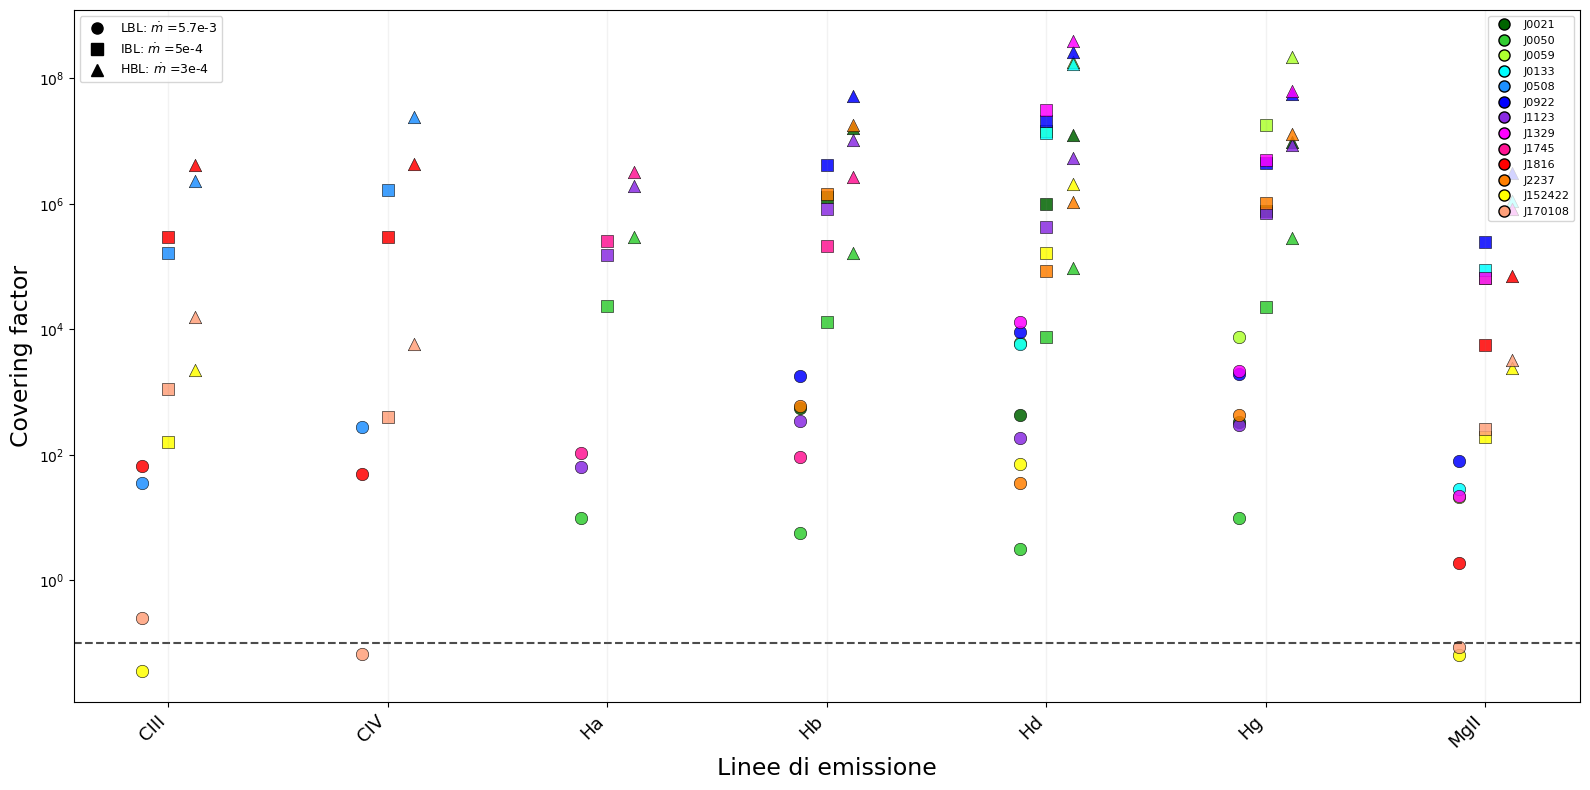

In [2]:
# ==========================================================
# GRAFICO GENERALE DEI COVERING FACTOR - STILE SS
# ==========================================================

df_plot_adaf = df_risultati_finali_adaf.copy()

df_plot_adaf["covering_factor"] = pd.to_numeric(
    df_plot_adaf["covering_factor"],
    errors="coerce",
)

df_plot_adaf = df_plot_adaf[
    df_plot_adaf["covering_factor"].notna()
    & (df_plot_adaf["covering_factor"] > 0)
].copy()

# Stesso ordine del grafico SS
ordine_linee = [
    "CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"
]

linee_presenti = (
    df_plot_adaf["line_name"]
    .dropna()
    .unique()
    .tolist()
)

linee_uniche = [
    linea
    for linea in ordine_linee
    if linea in linee_presenti
]

linee_uniche += [
    linea
    for linea in sorted(linee_presenti)
    if linea not in linee_uniche
]

x_map = {
    linea: i
    for i, linea in enumerate(linee_uniche)
}

df_plot_adaf["x_base"] = df_plot_adaf["line_name"].map(x_map)

# Tre scenari ADAF: offset simmetrici come nello stile SS
offset_values = np.linspace(-0.12, 0.12, len(ordine_scenari_adaf))
offset_scenario = dict(zip(ordine_scenari_adaf, offset_values))

df_plot_adaf["x"] = (
    df_plot_adaf["x_base"]
    + df_plot_adaf["scenario"].map(offset_scenario)
)

# Nomi corti e colori identici al programma SS
blazar_order = [
    "J0021",
    "J0050",
    "J0059",
    "J0133",
    "J0508",
    "J0922",
    "J1123",
    "J1329",
    "J1745",
    "J1816",
    "J2237",
    "J152422",
    "J170108",
]

colors = [
    "#006400",
    "#32cd32",
    "#adff2f",
    "#00ffff",
    "#1e90ff",
    "#0000ff",
    "#8a2be2",
    "#ff00ff",
    "#ff1493",
    "#ff0000",
    "#ff7f00",
    "#ffff00",
    "#ffa07a",
]


def trova_nome_corto(label):
    label = str(label)
    for blazar in blazar_order:
        if label.startswith(blazar):
            return blazar
    return label


df_plot_adaf["blazar_short"] = df_plot_adaf["label"].apply(trova_nome_corto)
color_map = dict(zip(blazar_order, colors))

ordine_blazar = [
    blazar
    for blazar in blazar_order
    if blazar in df_plot_adaf["blazar_short"].unique()
]

# Eventuali oggetti non presenti nella lista SS ricevono colori tab20
blazar_extra = [
    b
    for b in df_plot_adaf["blazar_short"].dropna().unique()
    if b not in ordine_blazar
]

if blazar_extra:
    cmap_extra = plt.get_cmap("tab20")
    for i, b in enumerate(blazar_extra):
        color_map[b] = cmap_extra(i % 20)
    ordine_blazar += sorted(blazar_extra)

print("CHECK DATI PER IL GRAFICO ADAF")
print("Numero punti:", len(df_plot_adaf))
print("Blazar presenti:", ordine_blazar)
print("Scenari presenti:", df_plot_adaf["scenario"].unique())
print("Linee presenti:", df_plot_adaf["line_name"].unique())
print("Cf min:", df_plot_adaf["covering_factor"].min())
print("Cf max:", df_plot_adaf["covering_factor"].max())

marker_list = ["o", "s", "^", "D", "v", "P", "X", "*"]
marker_map = {
    scenario: marker_list[i % len(marker_list)]
    for i, scenario in enumerate(ordine_scenari_adaf)
}

# Etichette scenario già definite in SCENARI_ADAF
scenario_label_map = {
    scenario: scenario
    for scenario in ordine_scenari_adaf
}

fig, ax = plt.subplots(figsize=(16, 8))

for scenario in ordine_scenari_adaf:
    df_s = df_plot_adaf[
        df_plot_adaf["scenario"] == scenario
    ]

    for blazar in ordine_blazar:
        df_b = df_s[
            df_s["blazar_short"] == blazar
        ]

        if df_b.empty:
            continue

        ax.scatter(
            df_b["x"],
            df_b["covering_factor"],
            color=color_map[blazar],
            marker=marker_map[scenario],
            s=80,
            alpha=0.85,
            edgecolors="black",
            linewidths=0.45,
        )

ax.set_yscale("log")

# Riferimento Cf = 0.1, come nel grafico SS
ax.axhline(
    0.1,
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
)

ax.set_xticks(range(len(linee_uniche)))
ax.set_xticklabels(
    linee_uniche,
    rotation=45,
    ha="right",
    fontsize=13,
)

ax.set_xlabel("Linee di emissione", fontsize=17)
ax.set_ylabel("Covering factor", fontsize=17)

for i in range(len(linee_uniche)):
    ax.axvline(
        i,
        color="gray",
        alpha=0.10,
        lw=1,
    )

legend_scenari = [
    Line2D(
        [0],
        [0],
        marker=marker_map[scenario],
        color="black",
        linestyle="None",
        markersize=8,
        label=scenario_label_map[scenario],
    )
    for scenario in ordine_scenari_adaf
]

leg1 = ax.legend(
    handles=legend_scenari,
    loc="upper left",
    fontsize=9,
    frameon=True,
)
ax.add_artist(leg1)

legend_blazar = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color_map[blazar],
        markeredgecolor="black",
        markersize=8,
        linestyle="None",
        label=blazar,
    )
    for blazar in ordine_blazar
]

ax.legend(
    handles=legend_blazar,
    loc="upper right",
    fontsize=8,
    frameon=True,
)

plt.tight_layout()
plt.show()
